<a href="https://colab.research.google.com/github/PadawanXXVI/kmeans-3d-cluster/blob/main/DS_202402_IA_Apriori_Parte1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Configurações Iniciais

- Instalação e importação de bibliotecas


In [ ]:
import warnings

def ignore_warnings():
  # Ignorar todos os warnings de Deprecation
  warnings.filterwarnings("ignore", category=DeprecationWarning)

  # Ignorar todos os FutureWarnings
  warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
!pip install pyvis
!pip install mlxtend
!pip install pandas
!pip install matplotlib
!pip install networkx
!pip install numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.4 MB/s eta 0:00:00


In [ ]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd
import random
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Analisar Base de Dados



*   Indicar a URL onde está o arquivo com as transações da Doceria
*   Carregar o arquivo em um Pandas Data Frame
*   Exibir as 10 primeiras linhas do Data Frame



In [ ]:
ignore_warnings

urlArquivo = 'https://drive.google.com/uc?export=download&id=1s2PWGqh40mWLW1O_fWXnBBBTINeRSXnc'

df = pd.read_csv(urlArquivo)

In [ ]:
ignore_warnings

print(df.head(10))

   Transaction           Item         date_time period_day weekday_weekend
0            1          Bread  30-10-2016 09:58    morning         weekend
1            2   Scandinavian  30-10-2016 10:05    morning         weekend
2            2   Scandinavian  30-10-2016 10:05    morning         weekend
3            3  Hot chocolate  30-10-2016 10:07    morning         weekend
4            3            Jam  30-10-2016 10:07    morning         weekend
5            3        Cookies  30-10-2016 10:07    morning         weekend
6            4         Muffin  30-10-2016 10:08    morning         weekend
7            5         Coffee  30-10-2016 10:13    morning         weekend
8            5         Pastry  30-10-2016 10:13    morning         weekend
9            5          Bread  30-10-2016 10:13    morning         weekend


head(n) - Utilizado para mostrar os n primeiros registros de um dataframe

In [ ]:
ignore_warnings

df.head(10)

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend
5,3,Cookies,30-10-2016 10:07,morning,weekend
6,4,Muffin,30-10-2016 10:08,morning,weekend
7,5,Coffee,30-10-2016 10:13,morning,weekend
8,5,Pastry,30-10-2016 10:13,morning,weekend
9,5,Bread,30-10-2016 10:13,morning,weekend


tail(n) - Utilizado para exibir os últimos n registros de um data frame

In [ ]:
df.tail(10)

,Transaction,Item,date_time,period_day,weekday_weekend
20497,9681,Tea,09-04-2017 14:30,afternoon,weekend
20498,9681,Spanish Brunch,09-04-2017 14:30,afternoon,weekend
20499,9681,Christmas common,09-04-2017 14:30,afternoon,weekend
20500,9682,Muffin,09-04-2017 14:32,afternoon,weekend
20501,9682,Tacos/Fajita,09-04-2017 14:32,afternoon,weekend
20502,9682,Coffee,09-04-2017 14:32,afternoon,weekend
20503,9682,Tea,09-04-2017 14:32,afternoon,weekend
20504,9683,Coffee,09-04-2017 14:57,afternoon,weekend
20505,9683,Pastry,09-04-2017 14:57,afternoon,weekend
20506,9684,Smoothies,09-04-2017 15:04,afternoon,weekend


sample(n) - Utilizado para mostrar n registros aleatórios do dataframe

In [ ]:
df.sample(10)

,Transaction,Item,date_time,period_day,weekday_weekend
5048,2515,Coffee,03-12-2016 11:21,morning,weekend
17983,8541,Tea,21-03-2017 14:37,afternoon,weekday
5197,2583,Tea,04-12-2016 10:51,morning,weekend
19702,9312,Coke,03-04-2017 13:48,afternoon,weekday
2033,983,Cookies,10-11-2016 13:43,afternoon,weekday
11683,5800,Farm House,02-02-2017 13:01,afternoon,weekday
3628,1761,Bread,20-11-2016 12:38,afternoon,weekend
18857,8927,Muffin,27-03-2017 15:32,afternoon,weekday
3835,1862,Tea,22-11-2016 12:34,afternoon,weekday
374,180,Tea,01-11-2016 08:22,morning,weekday


In [ ]:
# exibir os registros de 11 a 20 do DF
df[11:20]
df[21:30]

,Transaction,Item,date_time,period_day,weekday_weekend
21,10,Scandinavian,30-10-2016 10:25,morning,weekend
22,10,Medialuna,30-10-2016 10:25,morning,weekend
23,11,Bread,30-10-2016 10:27,morning,weekend
24,11,Medialuna,30-10-2016 10:27,morning,weekend
25,11,Bread,30-10-2016 10:27,morning,weekend
26,12,Jam,30-10-2016 10:30,morning,weekend
27,12,Coffee,30-10-2016 10:30,morning,weekend
28,12,Tartine,30-10-2016 10:30,morning,weekend
29,12,Pastry,30-10-2016 10:30,morning,weekend


In [ ]:
display(df[5000:])

,Transaction,Item,date_time,period_day,weekday_weekend
5000,2489,Pastry,03-12-2016 09:35,morning,weekend
5001,2489,Bread,03-12-2016 09:35,morning,weekend
5002,2490,Bread,03-12-2016 09:39,morning,weekend
5003,2491,Farm House,03-12-2016 09:43,morning,weekend
5004,2492,Scone,03-12-2016 09:45,morning,weekend
...,...,...,...,...,...
20502,9682,Coffee,09-04-2017 14:32,afternoon,weekend
20503,9682,Tea,09-04-2017 14:32,afternoon,weekend
20504,9683,Coffee,09-04-2017 14:57,afternoon,weekend
20505,9683,Pastry,09-04-2017 14:57,afternoon,weekend


In [ ]:
df.shape

(20507, 5)

In [ ]:
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas. \n\n")

O dataset possui 20507 linhas e 5 colunas. 




In [ ]:
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas. \n\n")
print(f"O dataset possui {df['Transaction'].nunique()} transações distintas. \n\n")
print(f"O dataset possui {df['Item'].nunique()} itens distintos. \n\n")

x = round(df.shape[0] / df['Transaction'].nunique(), 2)

print(f"Há, em média {x} itens por compra. \n\n\n\n")



O dataset possui 20507 linhas e 5 colunas. 


O dataset possui 9465 transações distintas. 


O dataset possui 94 itens distintos. 


Há, em média 2.17 itens por compra. 






In [ ]:
df['period_day'].value_counts()

,count
period_day,
afternoon,11569
morning,8404
evening,520
night,14


In [ ]:
df['Item'].value_counts()

,count
Item,
Coffee,5471
Bread,3325
Tea,1435
Cake,1025
Pastry,856
...,...
Adjustment,1
The BART,1
Olum & polenta,1


In [ ]:
df['Item'] = df['Item'].str.strip()
df['Item'] = df['Item'].str.lower()
df['Item'].value_counts()

,count
Item,
coffee,5471
bread,3325
tea,1435
cake,1025
pastry,856
...,...
adjustment,1
the bart,1
olum & polenta,1


In [ ]:
display(df.Item.value_counts().head(2))
display(df.Item.value_counts().head(10))

,count
Item,
coffee,5471
bread,3325


,count
Item,
coffee,5471
bread,3325
tea,1435
cake,1025
pastry,856
sandwich,771
medialuna,616
hot chocolate,590
cookies,540


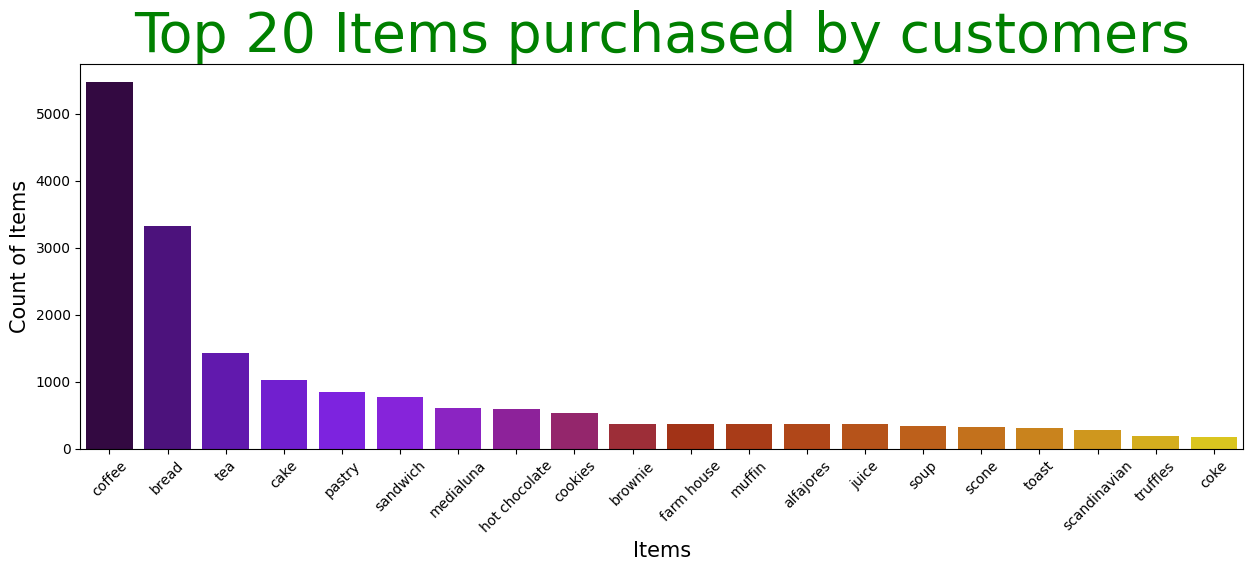

In [ ]:
plt.figure(figsize=(15,5))
sns.barplot(x = df.Item.value_counts().head(20).index, y = df.Item.value_counts().head(20).values, palette = 'gnuplot')
plt.xlabel('Items', size = 15)
plt.xticks(rotation=45)
plt.ylabel('Count of Items', size = 15)
plt.title('Top 20 Items purchased by customers', color = 'green', size = 40)
plt.show()

In [ ]:
df.head()

In [ ]:
# Converting the 'date_time' column into the right format
df['date_time'] = pd.to_datetime(df['date_time'])

# Extracting date
df['date'] = df['date_time'].dt.date

#Extracting time
df['time'] = df['date_time'].dt.time

# Extracting month and replacing it with text
df['month'] = df['date_time'].dt.month
df['month'] = df['month'].replace((1,2,3,4,5,6,7,8,9,10,11,12),
                                          ('01. January','02. February','03. March','04. April','05. May','06. June','07. July','08. August',
                                          '09. September','10. October','11. November','12. December'))

# Extracting hour
df['hour'] = df['date_time'].dt.hour
# Replacing hours with text
hour_in_num = (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23)
hour_in_obj = ('00-01','01-02','02-03','03-04', '04-05', '05-06', '06-07', '07-08','08-09','09-10','10-11','11-12','12-13','13-14','14-15',
               '15-16','16-17','17-18','18-19','19-20','20-21','21-22','22-23','23-24')
df['hour'] = df['hour'].replace(hour_in_num, hour_in_obj)

# Extracting weekday and replacing it with text
df['weekday'] = df['date_time'].dt.weekday
df['weekday'] = df['weekday'].replace((0,1,2,3,4,5,6),
                                          ('Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'))

# dropping date_time column
df.drop('date_time', axis = 1, inplace = True)

df.head()

/tmp/ipython-input-3129809383.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date_time'] = pd.to_datetime(df['date_time'])


,Transaction,Item,period_day,weekday_weekend,date,time,month,hour,weekday
0,1,bread,morning,weekend,2016-10-30,09:58:00,10. October,09-10,Sunday
1,2,scandinavian,morning,weekend,2016-10-30,10:05:00,10. October,10-11,Sunday
2,2,scandinavian,morning,weekend,2016-10-30,10:05:00,10. October,10-11,Sunday
3,3,hot chocolate,morning,weekend,2016-10-30,10:07:00,10. October,10-11,Sunday
4,3,jam,morning,weekend,2016-10-30,10:07:00,10. October,10-11,Sunday


In [ ]:
df['hour'].unique()

array(['09-10', '10-11', '11-12', '12-13', '13-14', '14-15', '08-09',
       '15-16', '17-18', '18-19', '07-08', '16-17', '19-20', '20-21',
       '21-22', '01-02', '23-24', '22-23'], dtype=object)

In [ ]:
df['month'].unique()

array(['10. October', '11. November', '12. December', '01. January',
       '02. February', '03. March', '04. April'], dtype=object)

In [ ]:
df['month'].nunique()

7

In [ ]:
df['month'].value_counts()

,count
month,
11. November,4436
03. March,3944
02. February,3906
01. January,3356
12. December,3339
04. April,1157
10. October,369


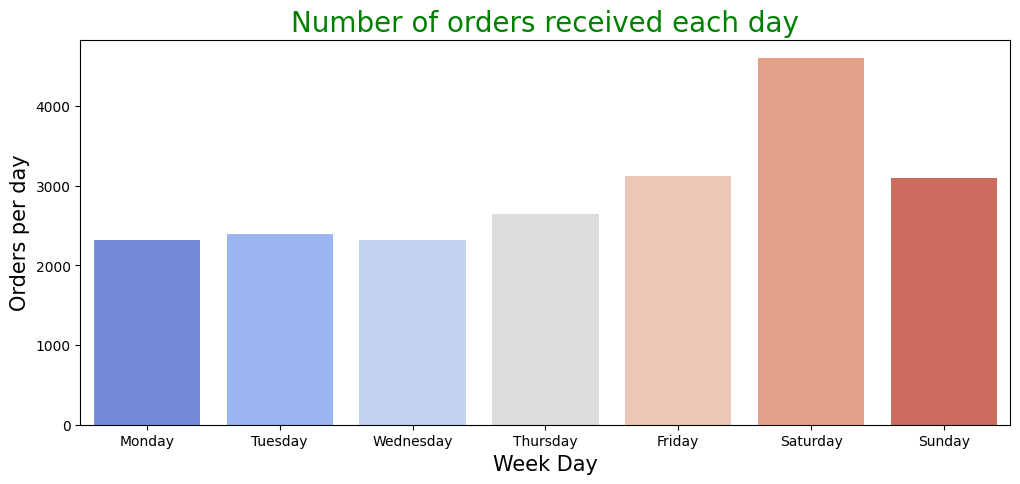

In [ ]:
weekTran = df.groupby('weekday')['Transaction'].count().reset_index()
weekTran.loc[:,"weekorder"] = [4,0,5,6,3,1,2]
weekTran.sort_values("weekorder",inplace=True)

plt.figure(figsize=(12,5))
sns.barplot(data = weekTran, x = "weekday", y = "Transaction",  palette = 'coolwarm')
plt.xlabel('Week Day', size = 15)
plt.ylabel('Orders per day', size = 15)
plt.title('Number of orders received each day', color = 'green', size = 20)
plt.show()

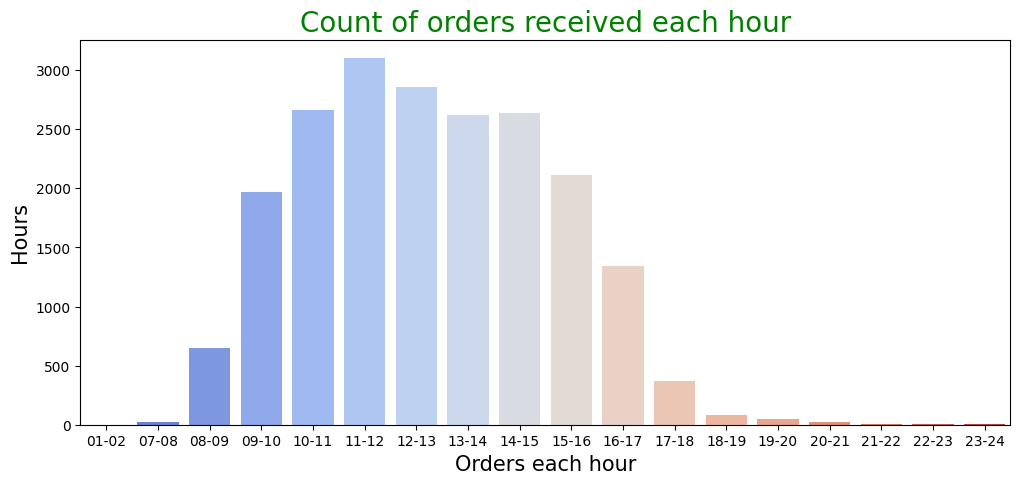

In [ ]:
hourTran = df.groupby('hour')['Transaction'].count().reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data = hourTran, y = "Transaction", x = "hour",  palette = 'coolwarm')
plt.ylabel('Hours', size = 15)
plt.xlabel('Orders each hour', size = 15)
plt.title('Count of orders received each hour', color = 'green', size = 20)
plt.show()

In [ ]:
display(df.head())
print("=======================")
dayTran = df.groupby('period_day')['Transaction'].count().reset_index()
dayTran.loc[:,"dayorder"] = [1,2,0,3]
dayTran.sort_values("dayorder",inplace=True)
display(dayTran)

,Transaction,Item,period_day,weekday_weekend,date,time,month,hour,weekday
0,1,bread,morning,weekend,2016-10-30,09:58:00,10. October,09-10,Sunday
1,2,scandinavian,morning,weekend,2016-10-30,10:05:00,10. October,10-11,Sunday
2,2,scandinavian,morning,weekend,2016-10-30,10:05:00,10. October,10-11,Sunday
3,3,hot chocolate,morning,weekend,2016-10-30,10:07:00,10. October,10-11,Sunday
4,3,jam,morning,weekend,2016-10-30,10:07:00,10. October,10-11,Sunday


,period_day,Transaction,dayorder
2,morning,8404,0
0,afternoon,11569,1
1,evening,520,2
3,night,14,3


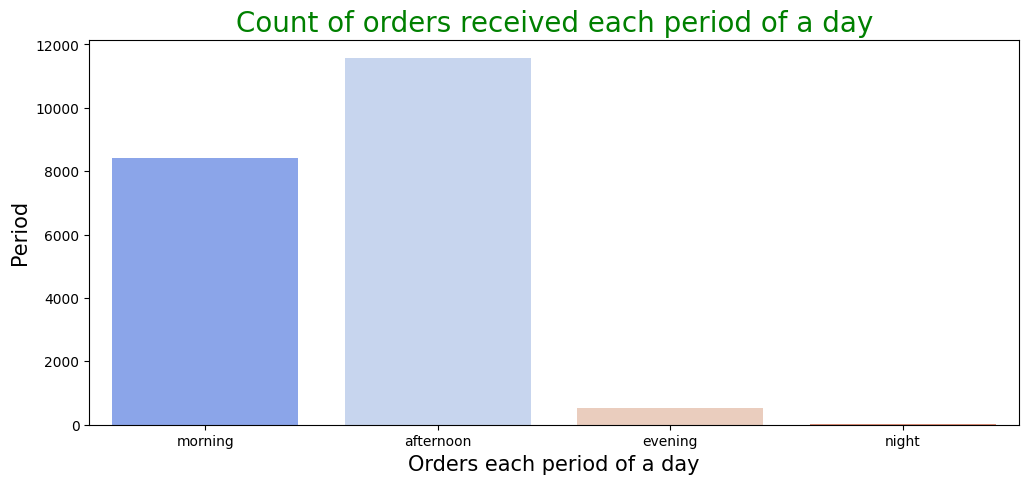

In [ ]:
#Preparando os dados para plotar no gráfico

#Agrupo os registros por "period_day", contando a quantidade de "Transaction"
dayTran = df.groupby('period_day')['Transaction'].count().reset_index()
dayTran.loc[:,"dayorder"] = [1,2,0,3]
dayTran.sort_values("dayorder",inplace=True)

plt.figure(figsize=(12,5))
sns.barplot(data = dayTran, y = "Transaction", x = "period_day",  palette = 'coolwarm')

plt.ylabel('Period', size = 15)
plt.xlabel('Orders each period of a day', size = 15)
plt.title('Count of orders received each period of a day', color = 'green', size = 20)
plt.show()

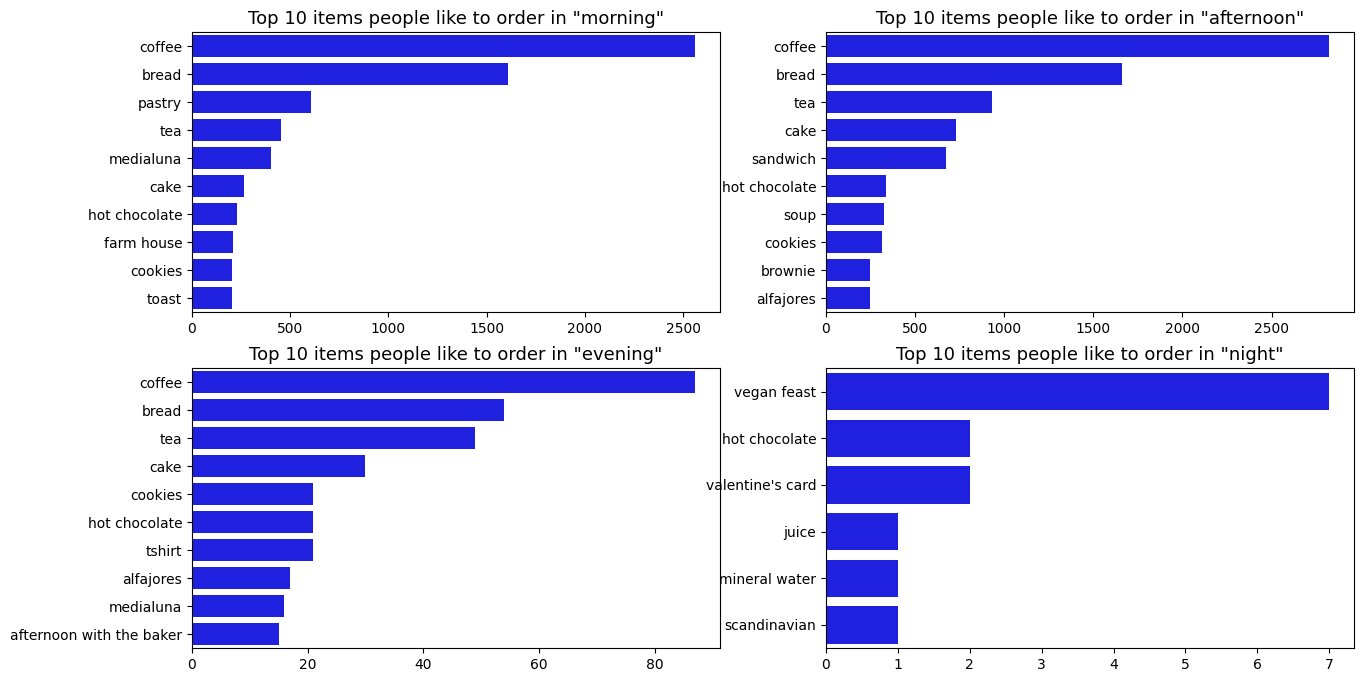

In [ ]:
data = df.groupby(['period_day','Item'])['Transaction'].count().reset_index().sort_values(['period_day','Transaction'],ascending=False)
day = ['morning','afternoon','evening','night']

plt.figure(figsize=(15,8))
for i,j in enumerate(day):
    plt.subplot(2,2,(i+1))
    df1 = data[data.period_day==j].head(10)
    sns.barplot(data=df1, y=df1.Item, x=df1.Transaction, color='blue')
    plt.xlabel('')
    plt.ylabel('')
    plt.title('Top 10 items people like to order in "{}"'.format(j), size=13)

plt.show()

In [ ]:
df.head()

#Explorando o Algoritmo Apriori com um Exemplo Prático

##Introdução

O algoritmo Apriori é amplamente utilizado na descoberta de regras de associação, sendo especialmente eficaz em identificar relações frequentes entre itens em grandes conjuntos de transações. Um exemplo típico é a análise de cestas de compras, onde podemos extrair padrões para identificar produtos frequentemente comprados juntos. Neste estudo, utilizaremos um conjunto de dados que registra transações de uma padaria, aplicando o algoritmo Apriori para descobrir padrões latentes e compreender as relações subjacentes entre os itens adquiridos.


##Passos para Análise com Apriori

Para aplicar o algoritmo Apriori, primeiro devemos preparar os dados de maneira que cada transação seja representada por um conjunto de itens. Em seguida, utilizamos o Apriori para extrair regras de associação e analisar conceitos importantes, como antecedente, consequente, suporte, confiança e lift.


In [ ]:
df

In [ ]:
from mlxtend.frequent_patterns import association_rules, apriori

transactions_str = df.groupby(['Transaction', 'Item'])['Item'].count().reset_index(name ='Count')
transactions_str

,Transaction,Item,Count
0,1,bread,1
1,2,scandinavian,2
2,3,cookies,1
3,3,hot chocolate,1
4,3,jam,1
...,...,...,...
18882,9682,tacos/fajita,1
18883,9682,tea,1
18884,9683,coffee,1
18885,9683,pastry,1


In [ ]:
my_basket = transactions_str.pivot_table(index='Transaction',
                                         columns='Item',
                                         values='Count',
                                         aggfunc='count').fillna(0)




my_basket.head()



Item,adjustment,afternoon with the baker,alfajores,argentina night,art tray,bacon,baguette,bakewell,bare popcorn,basket,...,the bart,the nomad,tiffin,toast,truffles,tshirt,valentine's card,vegan feast,vegan mincepie,victorian sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# agora mostre as 20 primeiras colunas
display(my_basket.iloc[:5, :20])

# agora mostre as 20 últimas colunas
display(my_basket.iloc[:5, -20:])

Item,adjustment,afternoon with the baker,alfajores,argentina night,art tray,bacon,baguette,bakewell,bare popcorn,basket,bowl nic pitt,bread,bread pudding,brioche and salami,brownie,cake,caramel bites,cherry me dried fruit,chicken sand,chicken stew
Transaction,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Item,scandinavian,scone,siblings,smoothies,soup,spanish brunch,spread,tacos/fajita,tartine,tea,the bart,the nomad,tiffin,toast,truffles,tshirt,valentine's card,vegan feast,vegan mincepie,victorian sponge
Transaction,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
def encode(x):
    if x<=0:
        return 0
    if x>=1:
        return 1

# applying the function to the dataset

my_basket_sets = my_basket.applymap(encode)
my_basket_sets.head()


Item,adjustment,afternoon with the baker,alfajores,argentina night,art tray,bacon,baguette,bakewell,bare popcorn,basket,...,the bart,the nomad,tiffin,toast,truffles,tshirt,valentine's card,vegan feast,vegan mincepie,victorian sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
display(my_basket_sets.iloc[:5, :20])

# agora mostre as 20 últimas colunas
display(my_basket_sets.iloc[:5, -20:])


Item,adjustment,afternoon with the baker,alfajores,argentina night,art tray,bacon,baguette,bakewell,bare popcorn,basket,bowl nic pitt,bread,bread pudding,brioche and salami,brownie,cake,caramel bites,cherry me dried fruit,chicken sand,chicken stew
Transaction,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


Item,scandinavian,scone,siblings,smoothies,soup,spanish brunch,spread,tacos/fajita,tartine,tea,the bart,the nomad,tiffin,toast,truffles,tshirt,valentine's card,vegan feast,vegan mincepie,victorian sponge
Transaction,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
frequent_items = apriori(my_basket_sets, min_support = 0.005,use_colnames = True)
frequent_items

,support,itemsets
0,0.036344,(alfajores)
1,0.016059,(baguette)
2,0.005071,(bakewell)
3,0.327205,(bread)
4,0.040042,(brownie)
...,...,...
109,0.007184,"(coffee, bread, sandwich)"
110,0.007396,"(bread, coffee, tea)"
111,0.006867,"(coffee, hot chocolate, cake)"
112,0.010037,"(coffee, tea, cake)"



## Conceitos:

**Antecedente**: Refere-se ao(s) item(ns) que precede(m) o consequente em uma regra de associação. Por exemplo, em uma regra do tipo "Se comprar Pão, então também compra Leite", o "Pão" é o antecedente.

**Consequente**: Corresponde ao(s) item(ns) que ocorre(m) após o antecedente. No exemplo anterior, "Leite" é o consequente.

**Suporte**: Mede a proporção de transações que contêm um determinado conjunto de itens. Essa métrica indica a relevância do conjunto de itens em todo o dataset, permitindo filtrar padrões pouco frequentes.

**Confiança**: Refere-se à probabilidade condicional de um consequente ser comprado, dado que o antecedente foi comprado. A confiança representa a força da implicação na regra de associação.

**Lift**: É uma métrica que quantifica o aumento na probabilidade de ocorrência do consequente, dado o antecedente, em comparação ao que seria esperado por mero acaso. Um valor de lift maior que 1 indica uma associação positiva e sugere que os itens têm maior probabilidade de serem comprados juntos do que se fossem independentes.



##Interpretação dos Resultados

Após aplicar o algoritmo Apriori, obtemos um conjunto de regras de associação que pode ser analisado para identificar padrões de compra. Cada regra é descrita por:

Antecedents (Antecedentes): Itens que constituem a premissa da regra.

Consequents (Consequentes): Itens que tendem a ser comprados quando os antecedentes ocorrem.

Support (Suporte): Frequência relativa da ocorrência conjunta dos antecedentes e consequentes no conjunto de dados.

Confidence (Confiança): Probabilidade de o consequente ser comprado, dado que o antecedente foi comprado.

Lift: Comparação da probabilidade de compra conjunta com o esperado em caso de independência dos itens.

Essas métricas ajudam a identificar regras que são estatisticamente significativas e comercialmente relevantes.


In [ ]:
rules = association_rules(frequent_items, metric = "lift", min_threshold = 1)
rules.sort_values('lift', ascending = False, inplace = True)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
52,(coke),(sandwich),0.019440,0.071844,0.005177,0.266304,3.706722,1.0,0.003780,1.265043,0.744697,0.060123,0.209513,0.169182
53,(sandwich),(coke),0.071844,0.019440,0.005177,0.072059,3.706722,1.0,0.003780,1.056705,0.786742,0.060123,0.053662,0.169182
56,(juice),(cookies),0.038563,0.054411,0.006128,0.158904,2.920442,1.0,0.004030,1.124234,0.683962,0.070560,0.110506,0.135763
57,(cookies),(juice),0.054411,0.038563,0.006128,0.112621,2.920442,1.0,0.004030,1.083457,0.695425,0.070560,0.077029,0.135763
97,(cake),"(coffee, hot chocolate)",0.103856,0.029583,0.006867,0.066124,2.235231,1.0,0.003795,1.039129,0.616663,0.054257,0.037655,0.149133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,(bread),(jam),0.327205,0.015003,0.005071,0.015499,1.033076,1.0,0.000162,1.000504,0.047588,0.015042,0.000504,0.176764
9,(brownie),(coffee),0.040042,0.478394,0.019651,0.490765,1.025860,1.0,0.000495,1.024293,0.026259,0.039398,0.023717,0.265921
8,(coffee),(brownie),0.478394,0.040042,0.019651,0.041078,1.025860,1.0,0.000495,1.001080,0.048327,0.039398,0.001079,0.265921
37,(coffee),(muffin),0.478394,0.038457,0.018806,0.039311,1.022193,1.0,0.000408,1.000888,0.041623,0.037760,0.000888,0.264161


In [ ]:
grules = rules[rules['lift'] > 2]
grules.shape

(12, 14)


##Exemplos de Regras e Métricas Importantes

Consideremos um exemplo de regra extraída:

Antecedente: toast

Consequente: coffee

Suporte: 0,02 (ou seja, 2% das transações contêm ambos os itens)

Confiança: 0,7 (isto é, 70% das vezes em que toast é comprado, coffee também é comprado)

Lift: 1,47 (este valor indica que a compra de Coffee é 47% mais provável na presença de toast do que seria esperado por acaso)



In [ ]:
grules

#Grafos

In [ ]:
from pyvis.network import Network
import pandas as pd
import random
from google.colab import files

# Criando a rede com cdn_resources configurado para 'remote' e habilitando física
net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white", notebook=True, directed=True, cdn_resources='in_line')

# Adicionando nós e arestas com setas
for index, row in grules.iterrows():
    antecedents = list(row['antecedents'])
    consequents = list(row['consequents'])

    # Adicionando cada antecedente como um nó
    for ant in antecedents:
        net.add_node(ant, ant, title=ant)

    # Adicionando cada consequente como um nó
    for con in consequents:
        net.add_node(con, con, title=con)

    # Adicionando arestas para cada par antecedente-consequente
    for ant in antecedents:
        for con in consequents:
            edge_title = f"Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}"
            net.add_edge(ant, con, value=row['confidence'], title=edge_title)


# Salvando e fazendo o download do grafo
net.save_graph("supermarket_associations_directed.html")
files.download("supermarket_associations_directed.html")




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>